<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>LLM Engineering Masterclass</h1>
<h1>1. Banking77 EDA and Prompts as Code</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [28]:
import os
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import watermark
from pydantic import BaseModel, Field, ValidationError
from typing import Literal

# Data downloads/cache and figure output locations
_ROOT = Path.cwd()
_DATA = _ROOT / "data"
_OUT = _ROOT / "output"
_DATA.mkdir(parents=True, exist_ok=True)
_OUT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("HF_HOME", str(_DATA / "huggingface"))
os.environ.setdefault("HF_DATASETS_CACHE", str(_DATA / "huggingface" / "datasets"))
os.environ.setdefault("KAGGLEHUB_CACHE", str(_DATA / "kagglehub"))

from collections import Counter
from pprint import pprint

%load_ext watermark
%matplotlib inline


The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark


In [29]:
%watermark -n -v -m -g -iv


Python implementation: CPython
Python version       : 3.14.5
IPython version      : 9.17.1

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.6.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 4a6dba6ecf328d3e09b6b48d7053d924ebc0545f

json         : 2.0.9
matplotlib   : 3.11.1
numpy        : 2.5.3
openai       : 3.13.0
pandas       : 3.0.5
pydantic     : 2.13.5
pydantic_core: 2.46.5
re           : 2.2.1
watermark    : 2.6.0



In [30]:
plt.style.use("d4sci.mplstyle")
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]


# The problem with prompts

A prompt edit ships on Friday. Quality drops all week. No test failed because no test exists.

This notebook builds three habits that stop the silent regression:

1. Prompts live in versioned files, not in code.
2. Outputs follow a schema, not free text.
3. Every prompt change runs against a regression suite.

First, the data. Every notebook in this masterclass works on the same real dataset, so we start by getting to know it.

# The dataset: Banking77

Banking77 ([Casanueva et al., 2020](https://arxiv.org/abs/2003.04807), CC BY 4.0) holds 13,083 real customer messages sent to an online bank, each labeled with one of 77 intents. It fits this workshop for three reasons:

1. The messages are real: short, informal, misspelled, ambiguous.
2. The labels are fine grained. Many intents sit one word apart.
3. It is small enough to evaluate against real APIs for cents.

We read the two CSV files straight from the PolyAI GitHub repository and cache them locally.

In [31]:
BANKING77_URL = ("https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/"
                 "master/banking_data/{split}.csv")

def load_raw(split):
    """Download once, then read from the local cache."""
    local = _DATA / f"banking77_{split}_raw.csv"
    if not local.exists():
        pd.read_csv(BANKING77_URL.format(split=split)).to_csv(local, index=False)
    return pd.read_csv(local)

train_raw = load_raw("train")
test_raw = load_raw("test")

print(f"train: {len(train_raw):,} rows   test: {len(test_raw):,} rows")
train_raw.sample(8, random_state=42)


train: 10,003 rows   test: 3,080 rows


,text,category
6883,Is it possible for me to change my PIN number?,change_pin
5836,I'm not sure why my card didn't work,declined_card_payment
8601,I don't think my top up worked,top_up_failed
2545,Can you explain why my payment was charged a fee?,card_payment_fee_charged
8697,How long does a transfer from a UK account tak...,balance_not_updated_after_bank_transfer
5573,Why am I getting declines when trying to make ...,declined_transfer
576,What is the $1 transaction on my account?,extra_charge_on_statement
6832,It looks like my card payment was sent back.,reverted_card_payment?


## Labels are data too

Before any modeling, check the label set for things that should not be there. Casing and stray punctuation in labels break every downstream join.

In [32]:
normalized = train_raw["category"].str.lower().str.rstrip("?")
quirks = sorted(set(train_raw["category"]) - set(normalized))
print("Labels that change under normalization:", quirks)


Labels that change under normalization: ['Refund_not_showing_up', 'reverted_card_payment?']


Two of the 77 labels needed fixing: one starts with a capital letter, one ends in a question mark. Normalize once, at load time, and every later notebook inherits clean labels.

In [33]:
def clean(df):
    out = df.rename(columns={"category": "intent"}).copy()
    out["intent"] = out["intent"].str.lower().str.rstrip("?")
    return out

train = clean(train_raw)
test = clean(test_raw)

INTENTS = sorted(train["intent"].unique())
print(len(INTENTS), "intents")
print(INTENTS[:5], "...", INTENTS[-3:])


77 intents
['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up'] ... ['why_verify_identity', 'wrong_amount_of_cash_received', 'wrong_exchange_rate_for_cash_withdrawal']


## Class balance

The training split is uneven, from a few dozen examples per intent to almost two hundred. The test split is exactly balanced: 40 messages per intent. That balance makes test accuracy easy to read, and we will lean on it when we build golden sets.

In [34]:
train_counts = train["intent"].value_counts()
test_counts = test["intent"].value_counts()

print("train examples per intent:", train_counts.describe()[["min", "50%", "max"]].to_dict())
print("test examples per intent: ", test_counts.unique())


train examples per intent: {'min': 35.0, '50%': 127.0, 'max': 187.0}
test examples per intent:  [40]


/var/folders/8g/hvs2bf_d4pv053525_0cfrz00000gn/T/ipykernel_17185/3503914224.py:6: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


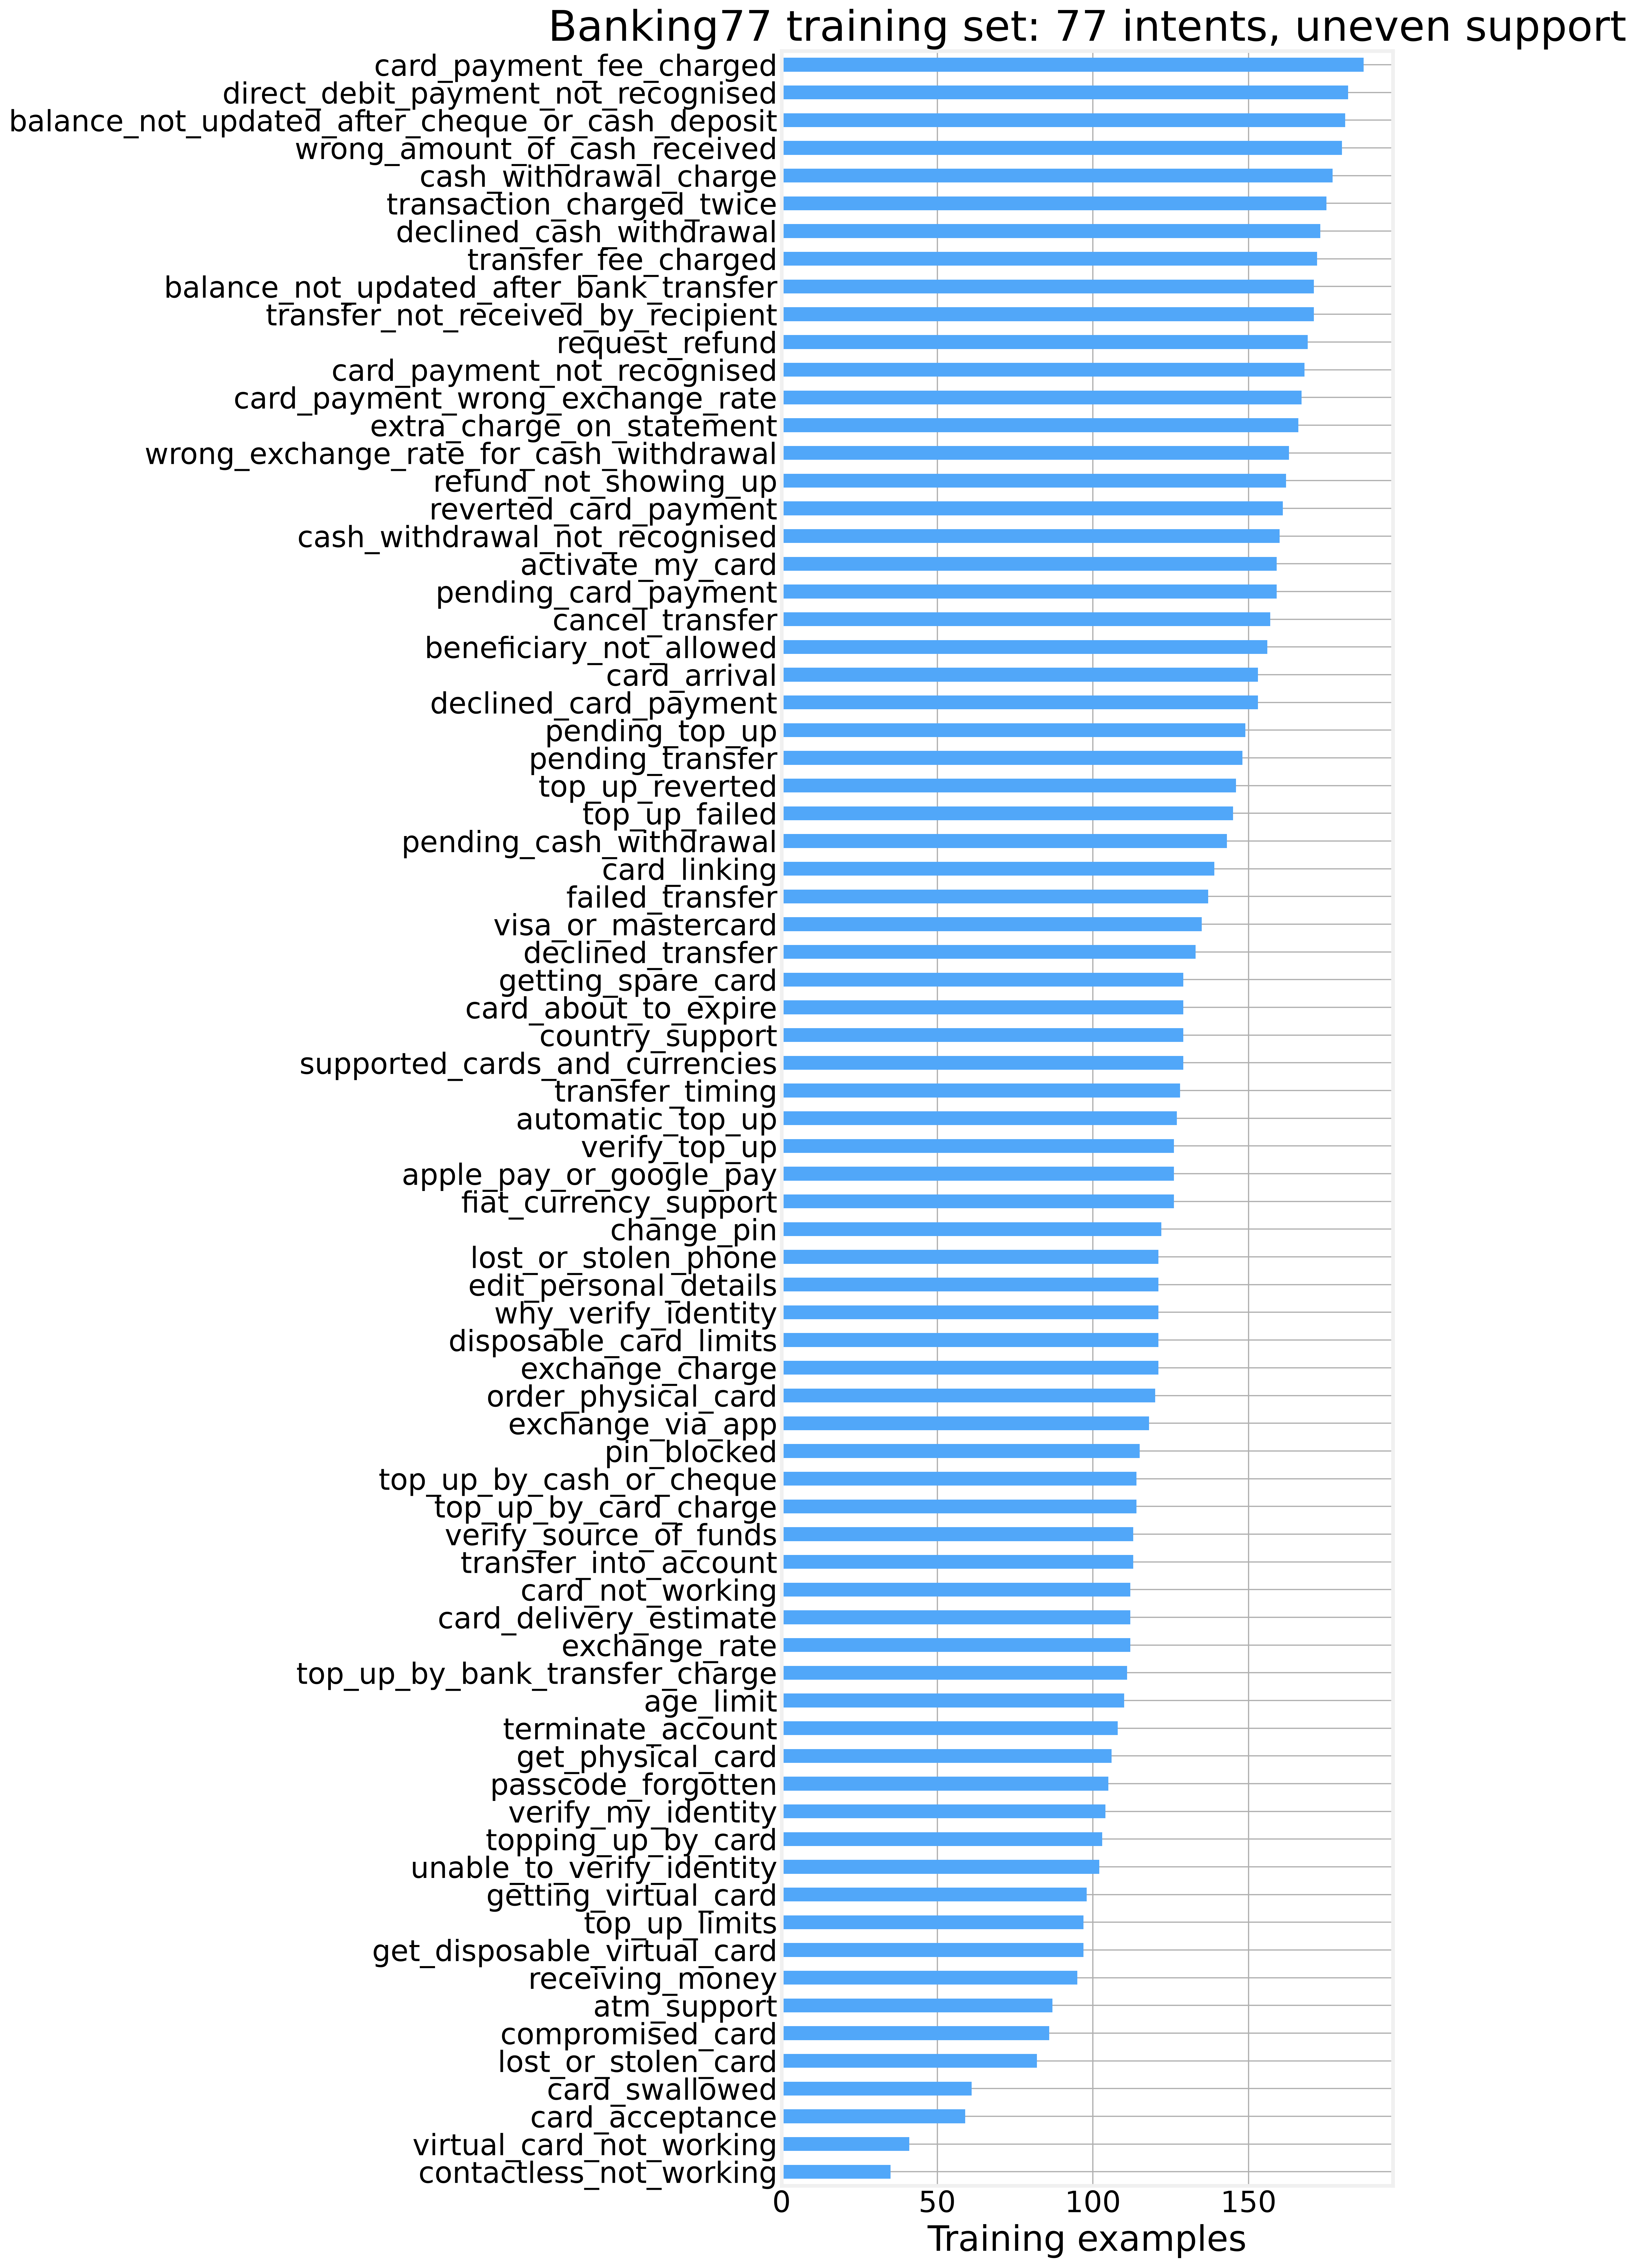

In [ ]:
fig, ax = plt.subplots(figsize=(8, 30))
train_counts.sort_values().plot.barh(ax=ax, color=colors[0])
ax.set_xlabel("Training examples")
ax.set_ylabel("")
ax.set_title("Banking77 training set: 77 intents, uneven support")
fig.tight_layout()

## Message length

Most messages fit in a tweet. A few run to a paragraph.

count    10003.0
mean        11.9
std          7.9
min          2.0
25%          7.0
50%         10.0
75%         13.0
max         79.0
Name: words, dtype: float64

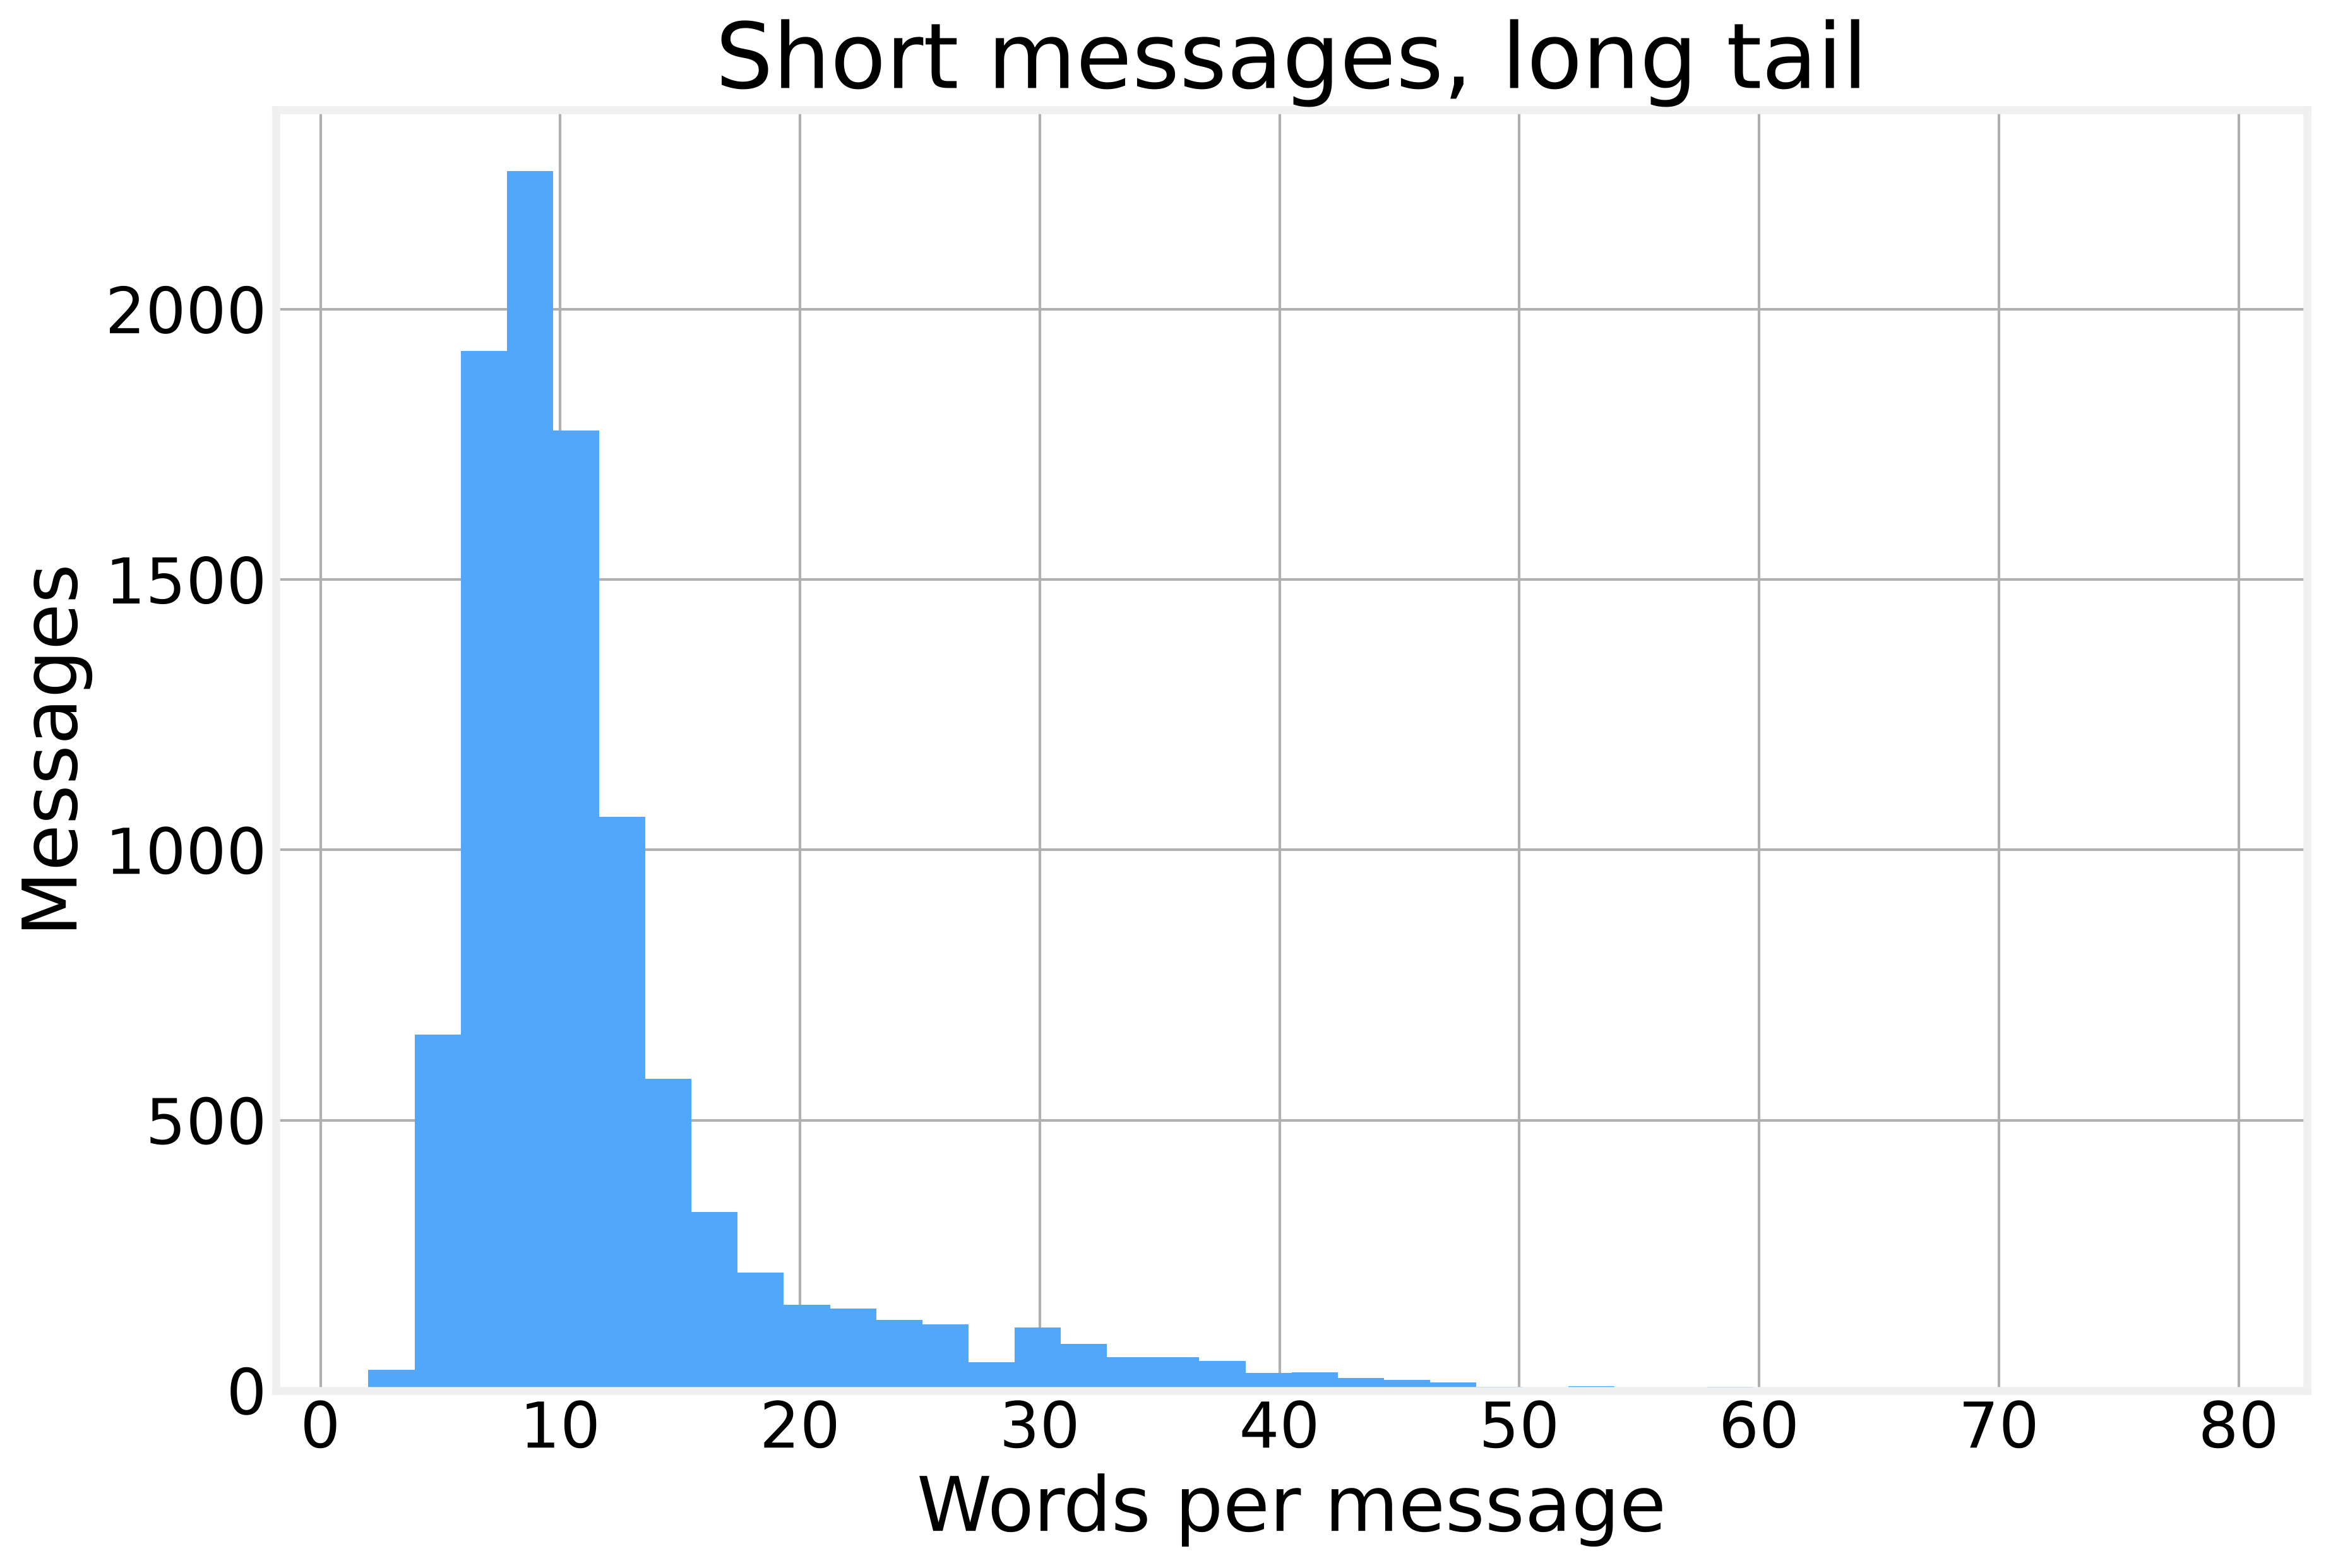

In [36]:
train["words"] = train["text"].str.split().str.len()

fig, ax = plt.subplots()
ax.hist(train["words"], bins=40, color=colors[0])
ax.set_xlabel("Words per message")
ax.set_ylabel("Messages")
ax.set_title("Short messages, long tail")
fig.tight_layout()

train["words"].describe().round(1)


## Leakage check

Duplicated texts and train/test overlap inflate every metric downstream. Thirty seconds now saves a wrong conclusion later.

In [37]:
print("duplicate texts in train:", train["text"].duplicated().sum())
print("texts shared by train and test:", len(set(train["text"]) & set(test["text"])))


duplicate texts in train: 0
texts shared by train and test: 0


## Fine grained means close neighbours

Three intents about transfers. Read the messages and try to tell them apart. This is the difficulty the model faces, and the reason evals need real examples.

In [38]:
for intent in ["pending_transfer", "transfer_timing", "transfer_not_received_by_recipient"]:
    print(f"\n{intent}")
    for text in test.loc[test["intent"] == intent, "text"].sample(3, random_state=1):
        print(f"  - {text}")



pending_transfer
  - Why is my transfer not done yet?
  - How long can I expect a transfer to pend for?
  - I have a pending transfer

transfer_timing
  - I need a fast transfer from China?  How fast will it be?
  - I have to transfer something to China as fast as I can. How long will it take to arrive in China?
  - how soon will I see the transfer in my account?

transfer_not_received_by_recipient
  - I am still waiting for a transaction to be completed
  - I sent my friend some money a few hours ago but she has not received it yet. She really needs it. How long does this take?
  - I made a money transaction but the recipient can't see it


# From 77 intents to 6 queues

A support team does not route on 77 labels. It routes on queues. Collapsing the taxonomy is a design decision, so we make it explicit, in code, with a rule that any reviewer can read.

We keep both levels. The queue is the routing decision. The intent is the fine grained diagnosis. Later notebooks measure both.

In [39]:
QUEUES = ["card", "payments", "transfers", "top_up", "account", "security"]

def queue_for(intent):
    """Route an intent to a support queue. Order matters: first match wins."""
    if any(key in intent for key in ("compromised", "lost_or_stolen", "not_recognised")):
        return "security"
    if "top_up" in intent or "topping_up" in intent:
        return "top_up"
    if any(key in intent for key in ("transfer", "beneficiary", "receiving_money", "deposit")):
        return "transfers"
    if any(key in intent for key in ("verify", "identity", "pin", "passcode", "personal_details",
                                     "terminate", "age_limit", "country_support", "fiat_currency")):
        return "account"
    if any(key in intent for key in ("payment", "refund", "charge", "exchange", "cash", "atm",
                                     "declined", "pending", "reverted", "wrong_amount", "statement")):
        return "payments"
    return "card"

INTENT_TO_QUEUE = {intent: queue_for(intent) for intent in INTENTS}
assert set(INTENT_TO_QUEUE.values()) <= set(QUEUES)

# Messages that always need a person: security incidents, closures, source of funds checks.
HUMAN_INTENTS = {"terminate_account", "verify_source_of_funds"}

def needs_human(intent):
    return INTENT_TO_QUEUE[intent] == "security" or intent in HUMAN_INTENTS

for queue in QUEUES:
    members = [intent for intent, q in INTENT_TO_QUEUE.items() if q == queue]
    print(f"{queue:10s} {len(members):2d} intents  e.g. {', '.join(members[:3])}")


card       19 intents  e.g. activate_my_card, apple_pay_or_google_pay, card_about_to_expire
payments   18 intents  e.g. atm_support, card_payment_fee_charged, card_payment_wrong_exchange_rate
transfers  12 intents  e.g. balance_not_updated_after_bank_transfer, balance_not_updated_after_cheque_or_cash_deposit, beneficiary_not_allowed
top_up     10 intents  e.g. automatic_top_up, pending_top_up, top_up_by_bank_transfer_charge
account    12 intents  e.g. age_limit, change_pin, country_support
security    6 intents  e.g. card_payment_not_recognised, cash_withdrawal_not_recognised, compromised_card


requires_human rate in test: 0.104


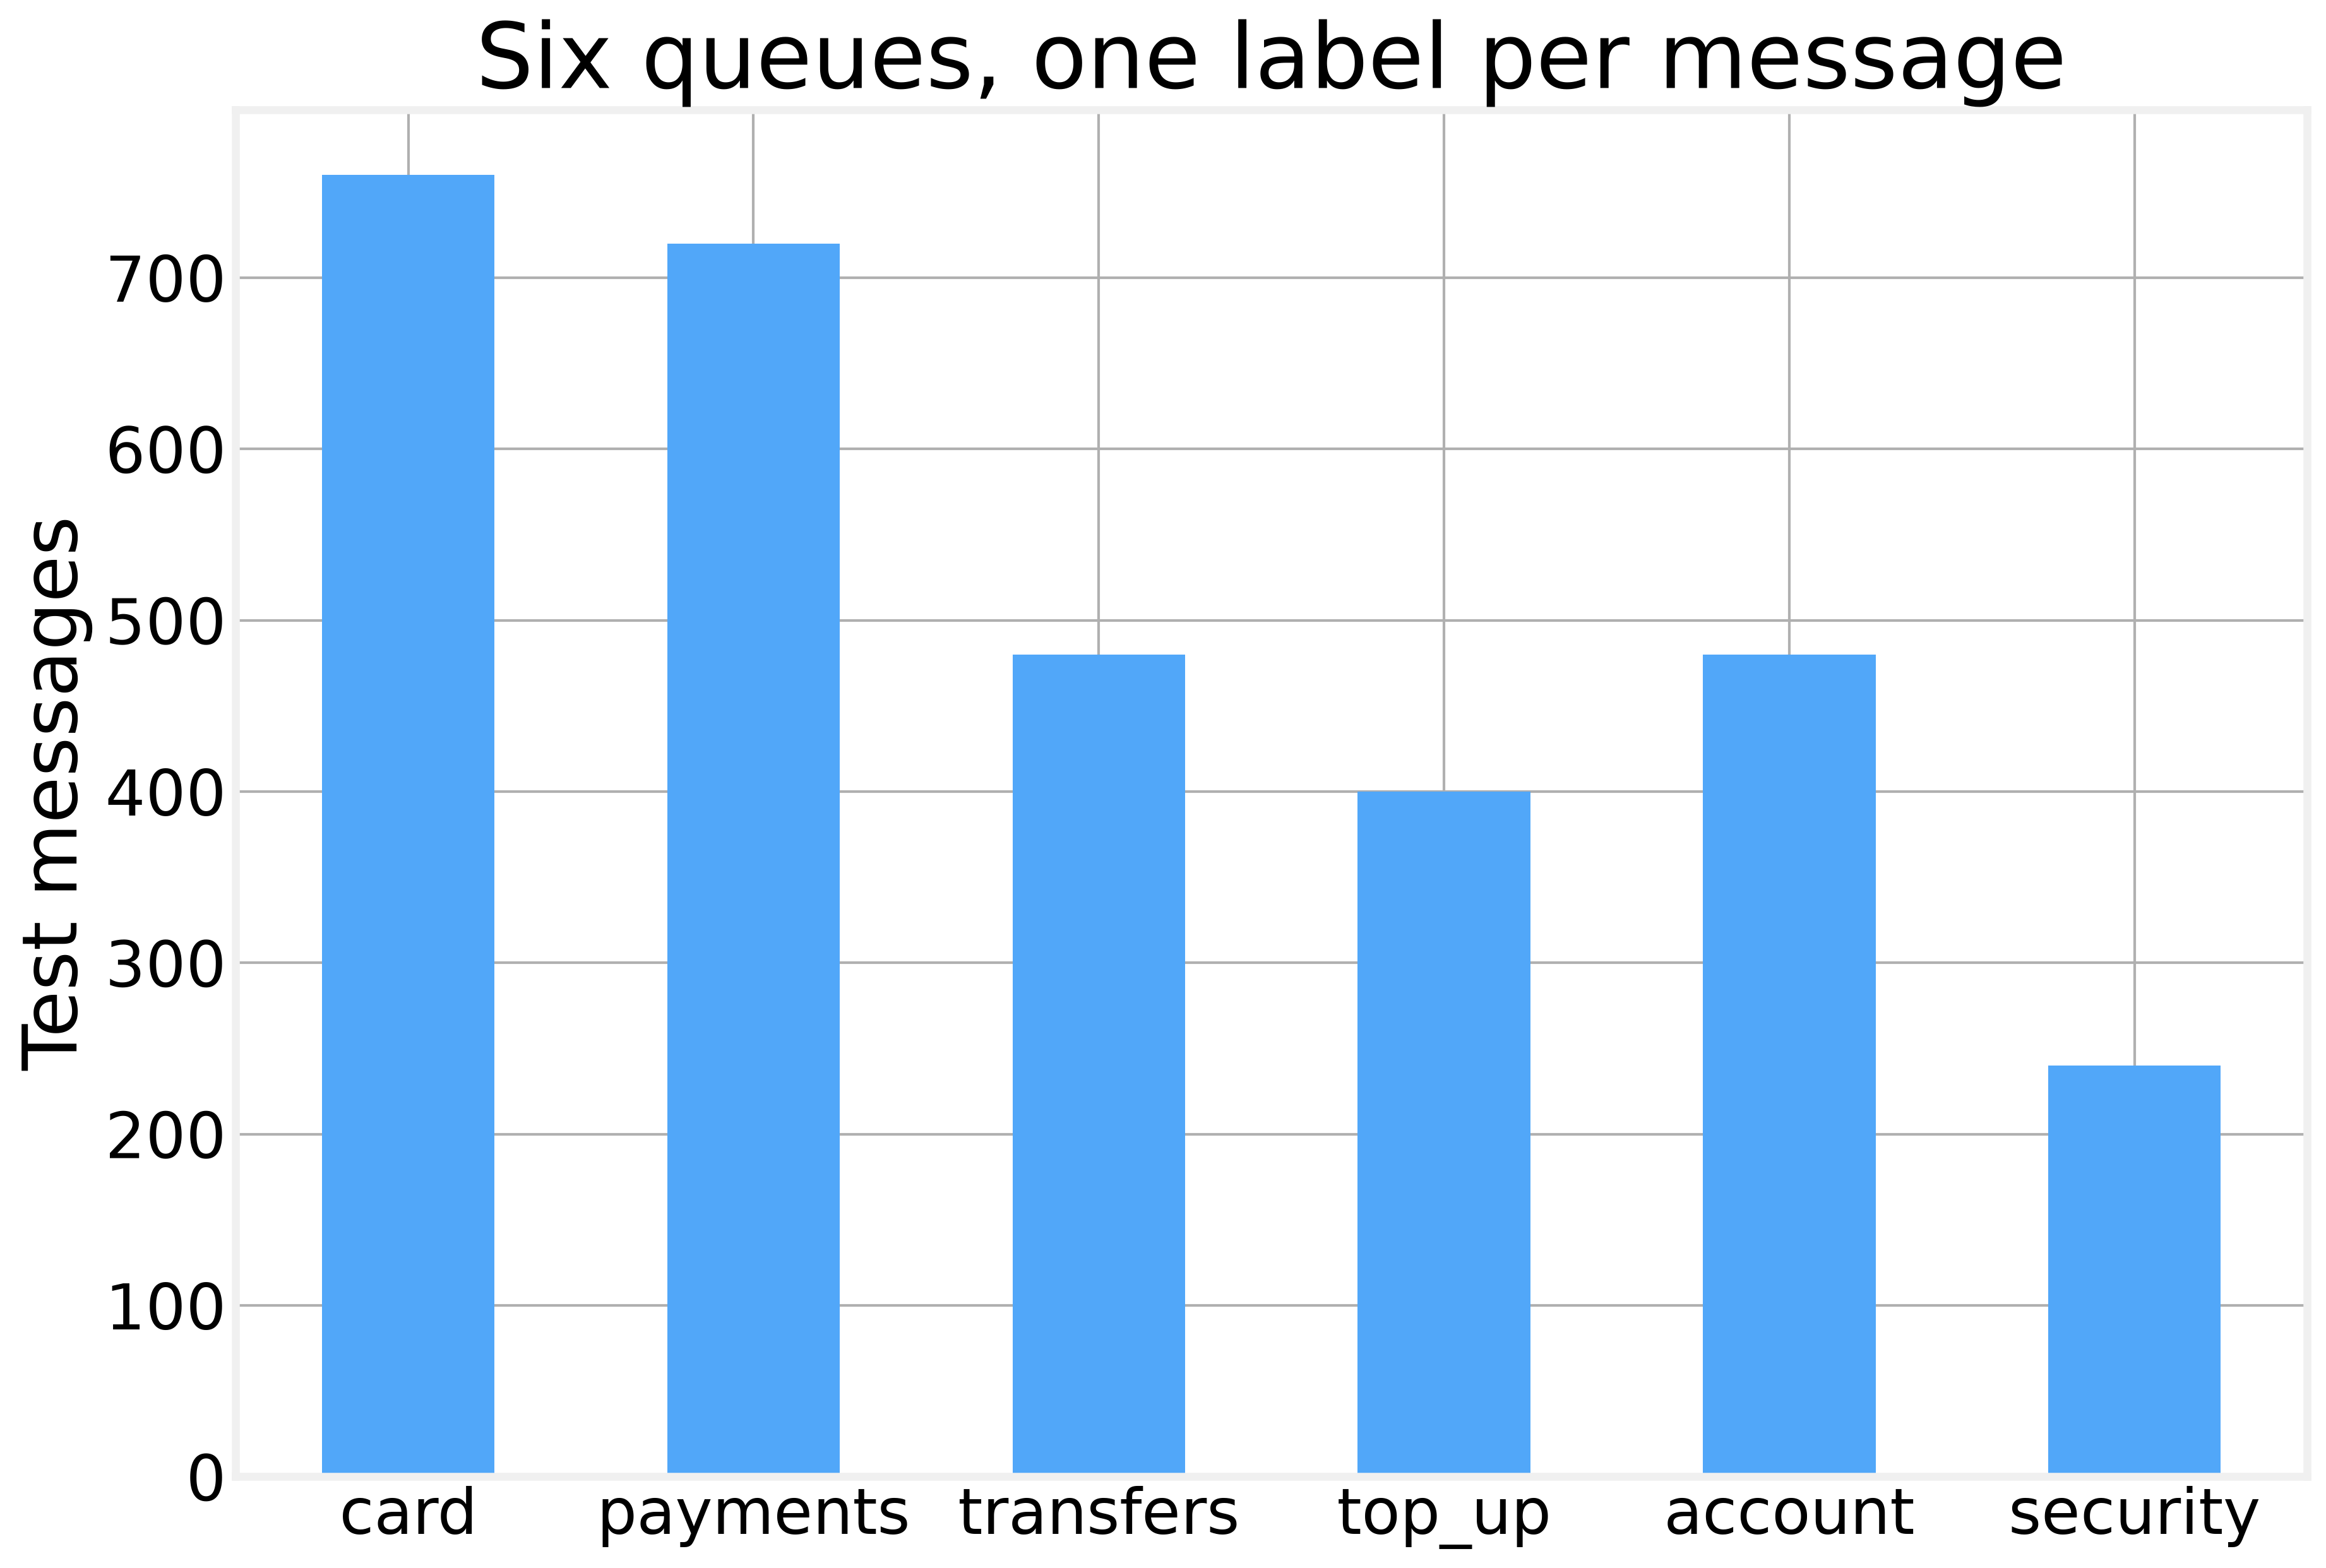

In [ ]:
for df in (train, test):
    df["queue"] = df["intent"].map(INTENT_TO_QUEUE)
    df["requires_human"] = df["intent"].map(needs_human)

queue_counts = test["queue"].value_counts().reindex(QUEUES)

fig, ax = plt.subplots()
queue_counts.plot.bar(ax=ax, color=colors[0])
ax.set_ylabel("Test messages")
ax.set_xlabel("")
ax.set_title("Six queues, one label per message")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()

print(f"requires_human rate in test: {test['requires_human'].mean():.3f}")


## Save the cleaned data

Every later notebook loads these files. The taxonomy travels with the data.

In [41]:
taxonomy = {
    "queues": QUEUES,
    "intents": INTENTS,
    "intent_to_queue": INTENT_TO_QUEUE,
    "human_intents": sorted(HUMAN_INTENTS),
}
(_DATA / "banking77_taxonomy.json").write_text(json.dumps(taxonomy, indent=2))

columns = ["text", "intent", "queue", "requires_human"]
train[columns].to_csv(_DATA / "banking77_train.csv", index=False)
test[columns].to_csv(_DATA / "banking77_test.csv", index=False)
print("Saved taxonomy and cleaned splits to", _DATA)


Saved taxonomy and cleaned splits to /Users/bgoncalves/My Drive/DataForScience/LLMEng/data


# One entry point for every model call

Hide the provider behind one function. Your application code never imports a vendor SDK directly. Swapping models becomes a one line change.

In [42]:
from openai import OpenAI

openai_client = OpenAI()

DEFAULT_MODEL = "gpt-4.1-mini"  # Any chat model works. Swap freely.

def call_model(messages, model=DEFAULT_MODEL, temperature=0.0, **kwargs):
    """One entry point for every model call in this masterclass."""
    if model.startswith("claude"):
        from anthropic import Anthropic

        system = ""
        chat = []
        for message in messages:
            if message["role"] == "system":
                system = message["content"]
            else:
                chat.append(message)
        # Anthropic SDK 1.x dropped temperature from messages.create(); current Claude models ignore it.
        response = Anthropic().messages.create(
            model=model,
            system=system,
            messages=chat,
            max_tokens=kwargs.pop("max_tokens", 1024),
        )
        # content[0] can be a thinking block. Join the text blocks.
        return "".join(block.text for block in response.content if block.type == "text")

    response = openai_client.chat.completions.create(
        model=model, messages=messages, temperature=temperature, **kwargs
    )
    return response.choices[0].message.content


# Version 0: the string in the code

Most LLM features start like this. We take a real message from the test set and ask.

In [43]:
message = test.loc[test["intent"] == "transaction_charged_twice", "text"].iloc[0]
print("Customer:", message)

answer = call_model([
    {"role": "user",
     "content": f"Which support queue should handle this message: {', '.join(QUEUES)}? "
                f"Message: {message}"},
])
print("Model:", answer)


Customer: I got double charged for a payment so how do I fix that?
Model: The message "I got double charged for a payment so how do I fix that?" should be handled by the **payments** support queue.


The reply is prose. Parsing it means regex and hope. The prompt itself has no version, no changelog and no owner. Time to fix all three.

# Habit 1: prompts as versioned artifacts

A prompt is a config file. Give it a name, a semantic version and a changelog. Store it next to your code and review it like code.

In [44]:
PROMPTS = _ROOT / "prompts"
PROMPTS.mkdir(exist_ok=True)

triage_v1 = {
    "name": "triage",
    "version": "1.0.0",
    "changelog": "Initial version.",
    "system": (
        "You triage customer messages for the support team of a mobile banking app.\n"
        "Reply with JSON only, using the keys queue, intent, summary and requires_human.\n"
        "Route each message to exactly one queue:\n"
        "card: physical or virtual cards, delivery, activation, contactless, card types.\n"
        "payments: card payments, ATM withdrawals, fees, exchange rates, refunds, duplicate charges.\n"
        "transfers: bank transfers in or out, timing, failures, beneficiaries, deposits.\n"
        "top_up: adding money to the account by card, bank transfer, cash or cheque.\n"
        "account: identity verification, PINs and passcodes, personal details, eligibility, closing the account.\n"
        "security: lost or stolen cards or phones, compromised cards, transactions the customer does not recognise.\n"
        "Pick the single most specific intent from the list provided.\n"
        "Write a one sentence summary under 30 words.\n"
        "Set requires_human to true for security incidents, account termination requests "
        "and source of funds checks."
    ),
    "user_template": "Message:\n{text}\n\nIntents (pick one):\n{intents}",
}

path = PROMPTS / "triage_v1.0.0.json"
path.write_text(json.dumps(triage_v1, indent=2))
print("Saved", path)


Saved /Users/bgoncalves/My Drive/DataForScience/LLMEng/prompts/triage_v1.0.0.json


In [45]:
def load_prompt(name, version=None):
    """Load a prompt by name. Latest version wins unless you pin one."""
    candidates = sorted(PROMPTS.glob(f"{name}_v*.json"))
    if version is not None:
        candidates = [p for p in candidates if p.stem.endswith(version)]
    if not candidates:
        raise FileNotFoundError(f"No prompt named {name!r} version {version!r}")
    return json.loads(candidates[-1].read_text())

def render(prompt, text):
    return [
        {"role": "system", "content": prompt["system"]},
        {"role": "user", "content": prompt["user_template"].format(text=text, intents=", ".join(INTENTS))},
    ]

prompt = load_prompt("triage")
prompt["version"]


'2.0.0'

# Habit 2: schemas, not string parsing

Declare the output shape once as a Pydantic model. You get runtime validation and a JSON schema for free. The 77 intents become an enum built from the data.

In [46]:
Queue = Literal[tuple(QUEUES)]
Intent = Literal[tuple(INTENTS)]  # 77 options, built from the data, never typed by hand

class Triage(BaseModel):
    queue: Queue
    intent: Intent
    summary: str
    requires_human: bool

schema = Triage.model_json_schema()
print(json.dumps(schema, indent=2)[:700], "...")


{
  "properties": {
    "queue": {
      "enum": [
        "card",
        "payments",
        "transfers",
        "top_up",
        "account",
        "security"
      ],
      "title": "Queue",
      "type": "string"
    },
    "intent": {
      "enum": [
        "activate_my_card",
        "age_limit",
        "apple_pay_or_google_pay",
        "atm_support",
        "automatic_top_up",
        "balance_not_updated_after_bank_transfer",
        "balance_not_updated_after_cheque_or_cash_deposit",
        "beneficiary_not_allowed",
        "cancel_transfer",
        "card_about_to_expire",
        "card_acceptance",
        "card_arrival",
        "card_delivery_estimate",
        "card_li ...


In [47]:
def extract_json(text):
    """Models sometimes wrap JSON in prose or code fences. Take the JSON part."""
    match = re.search(r"[\[{].*[\]}]", text, re.DOTALL)
    return match.group(0) if match else text

def triage(text, prompt=None, model=DEFAULT_MODEL):
    """Triage one message. Validate the output. Repair once on failure."""
    prompt = prompt or load_prompt("triage")
    messages = render(prompt, text)
    raw = call_model(messages, model=model)
    try:
        return Triage.model_validate_json(extract_json(raw))
    except ValidationError as error:
        # One repair attempt. Send the error back and ask for a fix.
        messages.append({"role": "assistant", "content": raw})
        messages.append({"role": "user",
                         "content": f"Your JSON failed validation:\n{error}\nReply with corrected JSON only."})
        raw = call_model(messages, model=model)
        return Triage.model_validate_json(extract_json(raw))

result = triage(message)
result


Triage(queue='card', intent='transaction_charged_twice', summary='Customer reports being double charged for a payment and seeks resolution.', requires_human=True)

### The native path

OpenAI enforces the schema during decoding when you pass the Pydantic model directly. Anthropic does the same through tool schemas. The validate and repair loop above works with any provider. Keep both in your toolbox.

In [48]:
completion = openai_client.chat.completions.parse(
    model=DEFAULT_MODEL,
    messages=render(prompt, message),
    response_format=Triage,
    temperature=0,
)

# Older SDK versions expose this as openai_client.beta.chat.completions.parse
completion.choices[0].message.parsed


Triage(queue='payments', intent='transaction_charged_twice', summary='Customer reports being double charged for a payment and wants to know how to fix it.', requires_human=False)

# Habit 3: regression tests for prompts

A handful of high signal cases with hard assertions. Run them on every prompt change, the same way you run unit tests on every code change.

In [49]:
TEST_CASES = [
    {"text": "Someone used my card in a shop I have never been to.",
     "expect": {"queue": "security", "requires_human": True}},
    {"text": "How long does a transfer to another bank take?",
     "expect": {"queue": "transfers", "requires_human": False}},
    {"text": "Please close my account, I no longer need it.",
     "expect": {"queue": "account", "requires_human": True}},
    {"text": "My top up by card failed twice today.",
     "expect": {"queue": "top_up", "requires_human": False}},
    {"text": "I was charged twice for the same coffee.",
     "expect": {"queue": "payments", "requires_human": False}},
]

def run_prompt_tests(prompt):
    rows = []
    for case in TEST_CASES:
        result = triage(case["text"], prompt=prompt)
        checks = {key: getattr(result, key) == value for key, value in case["expect"].items()}
        rows.append({"text": case["text"][:45] + "...", **checks, "passed": all(checks.values())})
    report = pd.DataFrame(rows)
    passed = report["passed"].sum()
    print(f"{passed}/{len(report)} passed on version {prompt['version']}")
    return report

run_prompt_tests(load_prompt("triage"))


2/5 passed on version 2.0.0


,text,queue,requires_human,passed
0,Someone used my card in a shop I have never b...,False,True,False
1,How long does a transfer to another bank take...,True,True,True
2,"Please close my account, I no longer need it....",True,True,True
3,My top up by card failed twice today....,True,False,False
4,I was charged twice for the same coffee....,False,False,False


### Now watch a plausible edit break production

Someone tightens the system prompt. The diff looks like a pure cleanup.

In [50]:
triage_v2 = dict(triage_v1)
triage_v2["version"] = "2.0.0"
triage_v2["changelog"] = "Shorter system prompt. Reads cleaner."
triage_v2["system"] = (
    "You triage customer messages for the support team of a mobile banking app. "
    "Reply with JSON only, using the keys queue, intent, summary and requires_human. "
    "Queues: card, payments, transfers, top_up, account, security. "
    "Pick the single most specific intent from the list provided. "
    "Write a one sentence summary under 30 words."
)

(PROMPTS / "triage_v2.0.0.json").write_text(json.dumps(triage_v2, indent=2))

run_prompt_tests(load_prompt("triage", version="2.0.0"))


2/5 passed on version 2.0.0


,text,queue,requires_human,passed
0,Someone used my card in a shop I have never b...,False,True,False
1,How long does a transfer to another bank take...,True,True,True
2,"Please close my account, I no longer need it....",True,True,True
3,My top up by card failed twice today....,True,False,False
4,I was charged twice for the same coffee....,False,False,False


The edit dropped the escalation policy. The `requires_human` checks fail and the suite catches it before a stolen card report sails past a human. A code review would call this diff harmless. The tests know better.

The same suite belongs in your repo as a real test file.

In [51]:
Path("tests").mkdir(exist_ok=True)


In [52]:
%%writefile tests/test_triage_prompt.py
"""Prompt regression suite. Runs in CI on every change under prompts/."""
import os

import pytest

requires_key = pytest.mark.skipif(
    not os.environ.get("OPENAI_API_KEY"), reason="needs an API key"
)

CASES = [
    ("Someone used my card in a shop I have never been to.", "security", True),
    ("How long does a transfer to another bank take?", "transfers", False),
    ("Please close my account, I no longer need it.", "account", True),
    ("My top up by card failed twice today.", "top_up", False),
    ("I was charged twice for the same coffee.", "payments", False),
]

@requires_key
@pytest.mark.parametrize("text,queue,requires_human", CASES)
def test_triage(text, queue, requires_human):
    from triage import triage  # your packaged version of this notebook

    result = triage(text)
    assert result.queue == queue
    assert result.requires_human == requires_human


Overwriting tests/test_triage_prompt.py


# Recap

1. Banking77: 13,083 real messages, 77 intents, two label quirks fixed at load time, six queues designed on purpose.
2. Prompts are versioned files with changelogs. `load_prompt` pins or floats.
3. Pydantic schemas replace string parsing. Validate, repair once, then fail loudly.
4. Five hard test cases caught a regression that a code review would wave through.

Five cases is a smoke alarm, not a measurement. Next we build the real yardstick: a golden dataset and an evaluation harness.

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>